In [ ]:
import kagglehub
import os
import shutil

target_dir = "dataset"

if not os.path.exists(target_dir):
    print("Dataset folder not found. Downloading...")

    cache_path = kagglehub.dataset_download("divyam6969/chest-xray-pneumonia-dataset")
    print("Downloaded to:", cache_path)

    shutil.copytree(cache_path, target_dir)
    print("Dataset saved to:", target_dir)

else:
    print("Dataset already exists. Skipping download.")


Dataset already exists. Skipping download.


# **Data Exploration & Understanding**

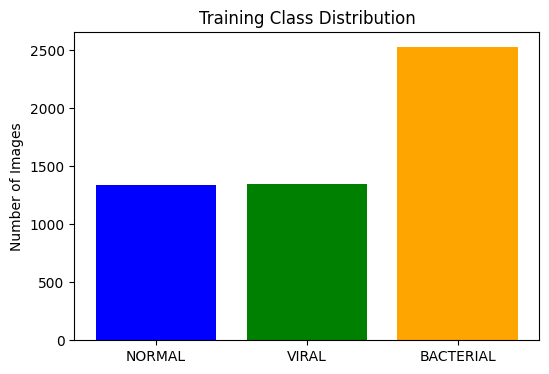

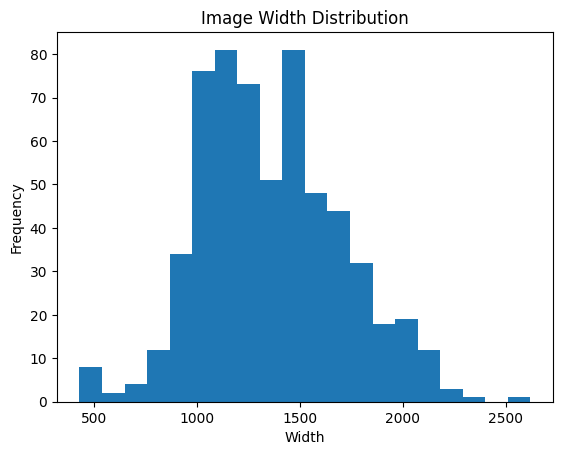

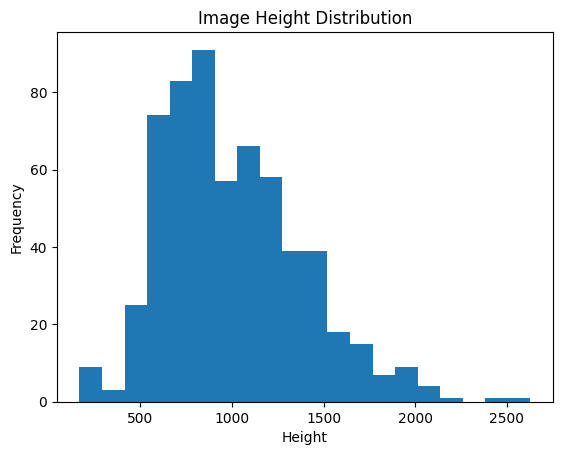

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

data_dir = "/content/dataset"
train_dir = f"{data_dir}/train"
test_dir = f"{data_dir}/test"

# ---Count Classes--- #
def count_classes(path):
  classes = os.listdir(path)
  result = {}

  for cls in classes:
    cls_path = os.path.join(path, cls)
    if os.path.isdir(cls_path):
      result[cls] = len(os.listdir(cls_path))

  return result

train_counts = count_classes(train_dir)
train_counts

# --- Plot Class Distribution --- #
plt.figure(figsize=(6,4))
plt.bar(train_counts.keys(), train_counts.values(), color=['blue', 'green', 'orange'])
plt.title("Training Class Distribution")
plt.ylabel("Number of Images")
plt.show()

# --- Image Sizes --- #
sizes = []

for cls in train_counts:
    folder = os.path.join(train_dir, cls)
    for img_name in os.listdir(folder)[:200]:
      img = Image.open(os.path.join(folder, img_name))
      sizes.append(img.size)

# --- Width Distribution --- #
widths = [s[0] for s in sizes]
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

# --- Height Distribution --- #
heights = [s[1] for s in sizes]
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

**Test-Folder-Fixing**

In [ ]:
import os
import shutil

test_path = "/content/dataset/test"

#create folders for the 3 classes
classes = ["NORMAL", "BACTERIAL", "VIRAL"]
for cls in classes:
    os.makedirs(os.path.join(test_path, cls), exist_ok=True)

#Move files into class folders based on filename
for file in os.listdir(test_path):
    fpath = os.path.join(test_path, file)
    if os.path.isfile(fpath):
      fname = file.lower()
      if "normal" in fname:
        shutil.move(fpath, os.path.join(test_path, "NORMAL", file))
      elif "bacteria" in fname or "bacterial" in fname:
        shutil.move(fpath, os.path.join(test_path, "BACTERIAL", file))
      elif "viral" in fname or "virus" in fname:
        shutil.move(fpath, os.path.join(test_path, "VIRAL", file))

# **Data Preprocessing**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# --- Data Augmentation for Training --- #
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.15
)

# --- For Test Set (NO augumentation) --- #
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# --- Data Generators --- #
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset="validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# --- Check Class Indicies --- #
train_generator.class_indices


Found 4435 images belonging to 3 classes.
Found 781 images belonging to 3 classes.
Found 40 images belonging to 3 classes.


{'BACTERIAL': 0, 'NORMAL': 1, 'VIRAL': 2}

# **Model Selection (MobileNetV2)**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Load MobileNetV2 without the top classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

#Freeze base model layers
base_model.trainable = False

#Build custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)  #3 classes

model = Model(inputs=base_model.input, outputs=output)

#Compile
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Model Training**

**1- Set Random Seed (Reproducibility)**

In [ ]:
import tensorflow as tf
import numpy as np
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

**2- Define Hyperparameters**

In [ ]:
EPOCHS = 15
BATCH_SIZE = 32
LR = 0.0001

**3- Define Callbacks (Checkpoint, Early Stopping, TensorBoard)**

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import datetime

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard = TensorBoard(log_dir=log_dir, histogram_freq=1)

**4- Train Model**

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[checkpoint, earlystop, tensorboard]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4700 - loss: 1.1792
Epoch 1: val_accuracy improved from -inf to 0.52500, saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.4706 - loss: 1.1778 - val_accuracy: 0.5250 - val_loss: 0.8058
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6665 - loss: 0.7339
Epoch 2: val_accuracy improved from 0.52500 to 0.65000, saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.6667 - loss: 0.7337 - val_accuracy: 0.6500 - val_loss: 0.7443
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7101 - loss: 0.6488
Epoch 3: val_accuracy improved from 0.65000 to 0.77500, saving model to best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.7102 - loss: 0.6487 - val_accuracy: 0.7750 - val_loss: 0.6623
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7291 - loss: 0.5996
Epoch 4: val_accuracy did not improve from

**5- Plot Accuracy & Loss Curves**

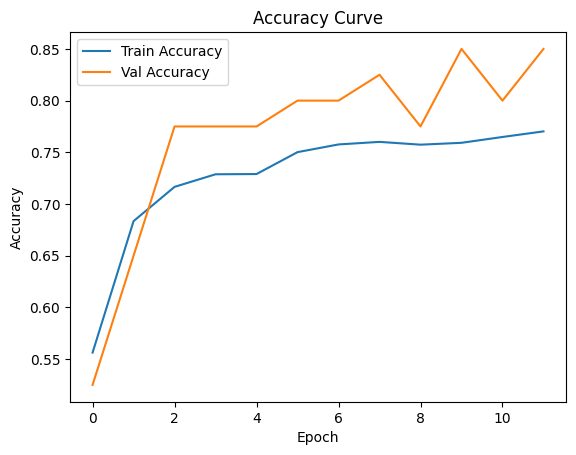

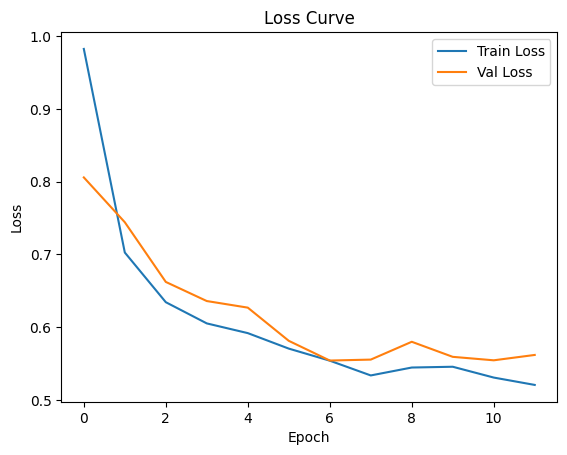

In [ ]:
import matplotlib.pyplot as plt

#Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Model Evaluation**

**1- Load Best Model**

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("best_model.keras")
best_model.save("best_model.keras")

**2- Evaluate Model on Test Set**

In [ ]:
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc: .4f}")
print(f"Test Loss: {test_loss: .4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - accuracy: 0.8479 - loss: 0.5638
Test Accuracy:  0.8500
Test Loss:  0.5595


**3- Generate Predictions**

In [ ]:
import numpy as np

y_pred = best_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


**4- Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_labels))

              precision    recall  f1-score   support

   BACTERIAL       0.86      0.90      0.88        20
      NORMAL       0.89      0.80      0.84        10
       VIRAL       0.80      0.80      0.80        10

    accuracy                           0.85        40
   macro avg       0.85      0.83      0.84        40
weighted avg       0.85      0.85      0.85        40



**5- Confusion Matrix**

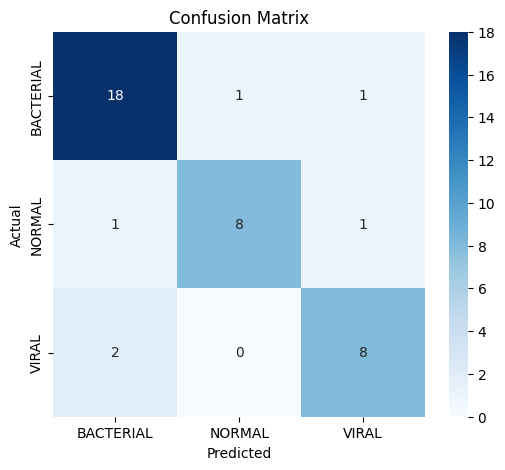

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**6- ROC Curve**

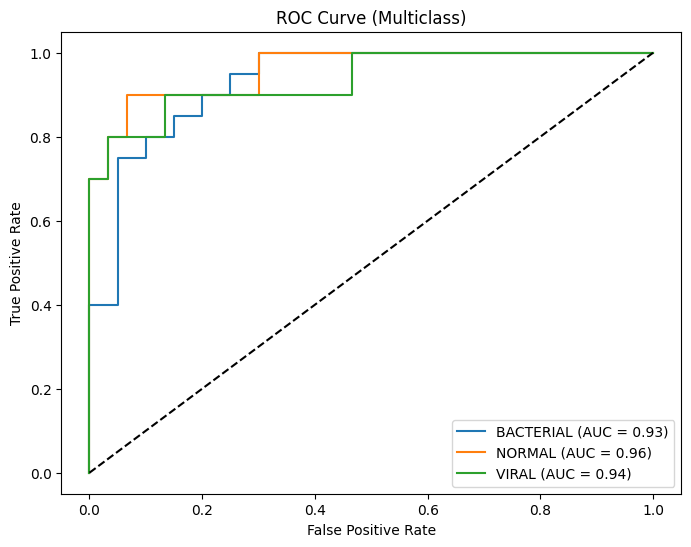

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve (Multiclass)")
plt.legend()
plt.show()

**7- Error Analysis**

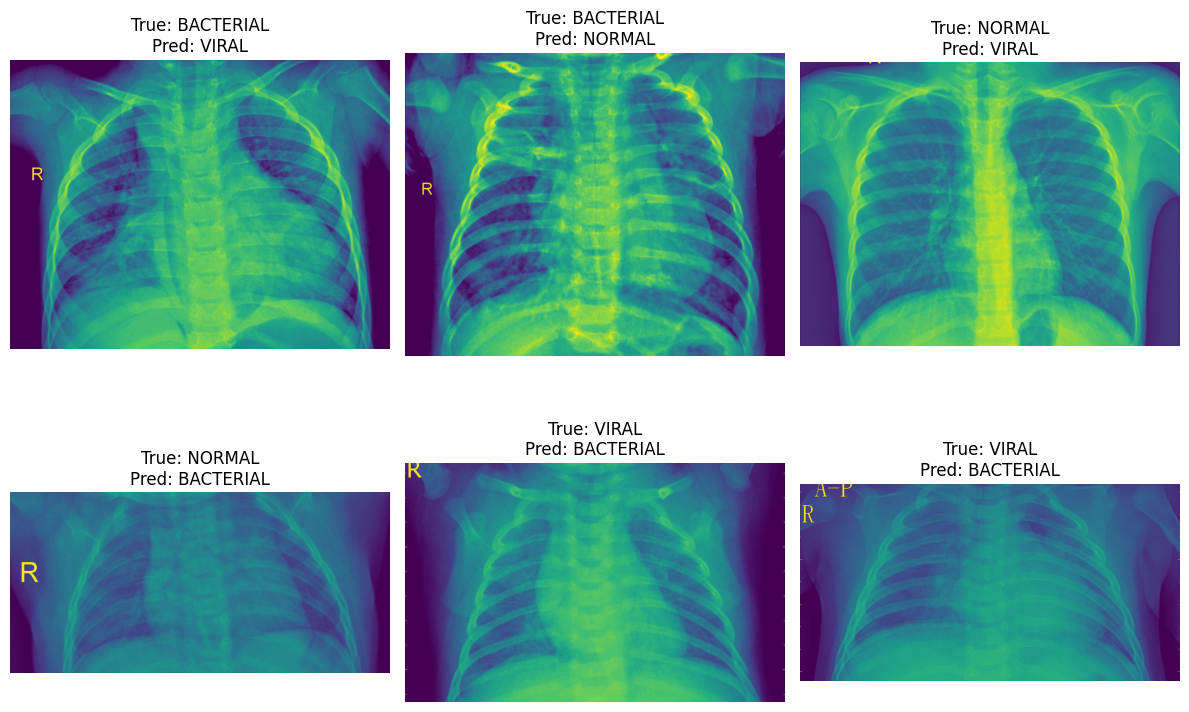

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# Assume test_generator, y_pred_classes, y_true, class_labels, test_dir are defined from previous cells

# Get the indices of misclassified images
errors = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(12,12))

# Get the list of filenames from the generator
# test_generator.filenames contains paths relative to test_dir, e.g., 'NORMAL/image.jpeg'
image_filenames = test_generator.filenames

for i, idx in enumerate(errors[:9]): # Display up to 9 error images
    # Get the relative path for the misclassified image
    relative_path = image_filenames[idx]
    # Construct the full path
    full_path = os.path.join(test_dir, relative_path)

    # Load the image
    img = Image.open(full_path)
    img_array = np.array(img) # Convert PIL Image to NumPy array

    plt.subplot(3,3,i+1)
    plt.imshow(img_array) # Display the original image
    plt.title(f"True: {class_labels[y_true[idx]]}\nPred: {class_labels[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

# **Model Optimization**

**1- Hyperparameter Tuning**

In [ ]:
LR_FINE = 1e-5
optimizer = tf.keras.optimizers.Adam(learning_rate=LR_FINE)

**2- Fine-Tuning the Base Model**

In [ ]:
# Unfreeze last X layers of MobileNetV2
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Compile with lower LR for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,845,891 (7.04 MB)

 Non-trainable params: 576,448 (2.20 MB)

**3- Train Again**

In [ ]:
history_finetune = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/5
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6840 - loss: 0.7085
Epoch 1: val_accuracy did not improve from 0.85000
139/139 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.6842 - loss: 0.7082 - val_accuracy: 0.6500 - val_loss: 0.8694
Epoch 2/5
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7363 - loss: 0.6017
Epoch 2: val_accuracy did not improve from 0.85000
139/139 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.7363 - loss: 0.6016 - val_accuracy: 0.7250 - val_loss: 0.9050
Epoch 3/5
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7518 - loss: 0.5591
Epoch 3: val_accuracy did not improve from 0.85000
139/139 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.7518 - loss: 0.5590 - val_accuracy: 0.7250 - val_loss: 0.9172
Epoch 4/5
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7767 - loss: 0.5267
Epoch 4: val_accuracy did not improve from 0.85000
139/139 ━━━━━━━━━━━━━━━━━━━━ 388s 2s/step - accuracy: 0.7767 - loss: 0.5268 - val_accuracy: 0.7500 - val_l

**4- Add Regularization**

In [ ]:
from tensorflow.keras.regularizers import l2

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0001))(x)

**5- Final Results**

In [ ]:
pred_prob = model.predict(test_generator)
pred = np.argmax(pred_prob, axis=1)
true = test_generator.classes

print(classification_report(true, pred))
cm = confusion_matrix(true, pred)
cm

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 465ms/step
              precision    recall  f1-score   support

           0       0.79      0.95      0.86        20
           1       1.00      0.60      0.75        10
           2       0.70      0.70      0.70        10

    accuracy                           0.80        40
   macro avg       0.83      0.75      0.77        40
weighted avg       0.82      0.80      0.79        40



array([[19,  0,  1],
       [ 2,  6,  2],
       [ 3,  0,  7]])

# **Evaluation After Fine-Tuning**

**Load Final Tuned Model**

In [ ]:
from tensorflow.keras.models import load_model
final_model = load_model("best_model.keras")

**Create test generator**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 40 images belonging to 3 classes.


**Predict on Test Set**

In [ ]:
import numpy as np

y_pred = final_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step


**Accuracy Curve (After Fine-Tuning)**

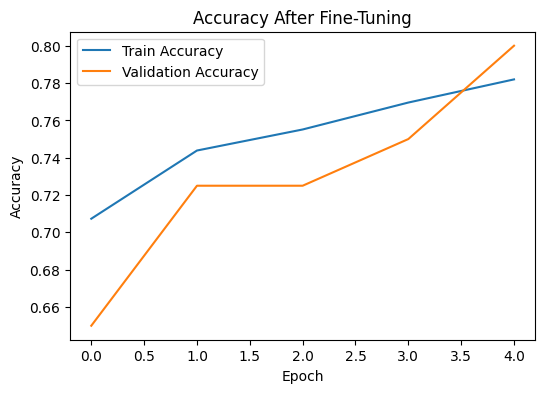

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy After Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Loss Curve (After Fine-Tuning)**

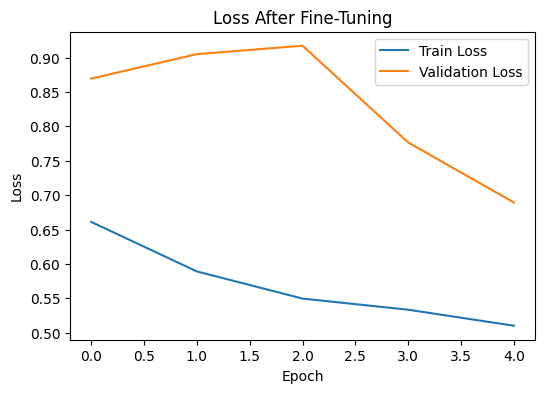

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Loss After Fine-Tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.save("best_model.keras")